In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.ensemble import VotingClassifier
!pip install lightgbm

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

Defaulting to user installation because normal site-packages is not writeable


In [2]:
ARTIFACTS_DIR = Path("artifacts")
RESULTS_DIR = Path("results")
SHAP_DIR = RESULTS_DIR / "shap"

RESULTS_DIR.mkdir(exist_ok=True)
SHAP_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
train = pd.read_csv("feature_engineering_datasets\\train_scaled.csv")
test = pd.read_csv("feature_engineering_datasets\\test_scaled.csv")

In [4]:
train.head()

,age,tenure_months,monthly_spend,last_login_days,support_tickets,is_active,suspicion_score,txn_per_day,spend_per_txn,spend_per_day,...,support_per_txn,txn_spend_ratio,activity_score,risk_score,spend_country_z,txn_country_z,gender_binary,country_freq,pm_freq,target_fraud
0,1.032617,-1.677100,-0.534606,0.373268,0.148020,-1.024808,-0.777861,-0.371908,-0.426678,-0.644359,...,-0.248614,1.608126,-0.917018,-0.264572,-0.560594,0.058176,1.011061,-0.894515,0.905240,0
1,-1.249744,1.395323,-1.080305,0.253965,0.846228,0.975793,-0.777861,-0.493911,-0.226454,-0.399018,...,0.013887,-0.263748,-0.018345,-0.338097,-1.004883,-0.553221,-0.989060,-0.304288,-1.408912,1
2,-0.377076,1.040813,-0.273702,-1.535574,0.148020,0.975793,-0.777861,-0.536680,1.838367,2.176571,...,1.689223,-0.340371,-1.729985,-0.428430,-0.302506,-1.577660,-0.989060,-0.894515,0.905240,0
3,0.294206,-0.259058,0.107444,1.327689,0.148020,0.975793,-0.777861,-0.713457,0.175660,-0.448137,...,0.378091,-0.319603,-0.853143,-0.604226,0.181056,-1.281577,1.011061,-0.304288,-1.408912,0
4,0.629848,-0.908994,1.310913,0.611873,-1.597500,0.975793,0.605003,-0.096773,-0.346776,-0.406593,...,-0.495998,-0.147614,1.054726,-0.683618,1.305849,1.570738,1.011061,1.627361,-1.408912,0


In [5]:
y_train = train["target_fraud"]
X_train = train.drop(['target_fraud'], axis = 1)

y_val = test["target_fraud"]
X_val = test.drop(['target_fraud'], axis = 1)

In [6]:
# !pip install imblearn
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)

# X_train, y_train = smote.fit_resample(X_train, y_train)

In [7]:
# from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(
#     X,
#     y,
#     test_size=0.2,      # 20% for testing
#     random_state=42,    # reproducible results
#     stratify=y          # keeps class distribution balanced
# )


In [8]:
# X_train = np.load(ARTIFACTS_DIR / "X_train.npy")
# X_val = np.load(ARTIFACTS_DIR / "X_val.npy")

# y_train = np.load(ARTIFACTS_DIR / "y_train.npy")
# y_val = np.load(ARTIFACTS_DIR / "y_val.npy")

# feature_columns = joblib.load(
#     ARTIFACTS_DIR / "feature_columns.pkl"
# )

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (4000, 24)
X_val shape: (1000, 24)


In [9]:
fraud_rate_train = np.mean(y_train)

print("Fraud Rate:", fraud_rate_train)

Fraud Rate: 0.1715


In [10]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_pos_weight = neg / pos

print("Negative samples:", neg)
print("Positive samples:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 3314
Positive samples: 686
scale_pos_weight: 4.830903790087463


In [11]:
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    pr_auc = average_precision_score(y_true, y_prob)

    return {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR_AUC": pr_auc
    }

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [13]:
log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

In [14]:
log_cv_results = cross_validate(
    log_reg,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

print("Average PR-AUC:",
      log_cv_results['test_pr_auc'].mean())

Average PR-AUC: 0.35370941679878876


In [15]:
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [16]:
log_val_prob = log_reg.predict_proba(X_val)[:, 1]

In [17]:
baseline_metrics = evaluate_model(
    y_val,
    log_val_prob
)

baseline_metrics

{'Precision': 0.26756756756756755,
 'Recall': 0.5892857142857143,
 'F1': 0.3680297397769517,
 'PR_AUC': np.float64(0.37025870144036876)}

In [18]:
with open(RESULTS_DIR / "baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

In [19]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist'
)

In [20]:
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400, 600],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

In [21]:
xgb_grid = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=100,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [22]:
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 400, 600],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [23]:
best_xgb = xgb_grid.best_estimator_

print("Best Parameters:")
print(xgb_grid.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


In [24]:
xgb_val_prob = best_xgb.predict_proba(X_val)[:, 1]

xgb_metrics = evaluate_model(
    y_val,
    xgb_val_prob
)

xgb_metrics

{'Precision': 0.3333333333333333,
 'Recall': 0.5476190476190477,
 'F1': 0.4144144144144144,
 'PR_AUC': np.float64(0.44908462278798333)}

In [25]:
param_dist = {
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 4, 6, 8],
    'min_child_samples': [10, 20, 40],

    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [400, 800, 1200],

    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],

    'reg_alpha': [0.0, 0.1, 0.3],
    'reg_lambda': [0.5, 1.0, 2.0]
}

In [26]:
lgbm_model = LGBMClassifier(
    andom_state=42,
    objective='binary',
    scale_pos_weight=scale_pos_weight,

    # 🔥 added stability improvements (IMPORTANT for PR-AUC)
    n_estimators=800,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8
)

lgb_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist,
    n_iter=100,   # IMPORTANT (fast but effective)
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

lgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Info] Number of positive: 686, number of negative: 3314
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171500 -> initscore=-1.575034
[LightGBM] [Info] Start training from score -1.575034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(andom_state=42,
                                            colsample_bytree=0.8,
                                            learning_rate=0.03,
                                            n_estimators=800,
                                            objective='binary',
                                            scale_pos_weight=np.float64(4.830903790087463),
                                            subsample=0.8),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.03, 0.05],
                                        'max_depth': [-1, 4, 6, 8],
                                        'min_child_samples': [10, 20, 40],
                                        'n_estimators': [400, 800, 1200],
                                        'num_leaves': [15, 31, 63],
                                        'reg_alpha': [0.0, 0.1, 0.3],
                                        'reg_lambda': [0.5, 1.0, 2.0],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [27]:
lgbm_val_prob = lgb_search.predict_proba(X_val)[:, 1]

lgbm_metrics = evaluate_model(
    y_val,
    lgbm_val_prob
)

lgbm_metrics

[LightGBM] [Warning] Unknown parameter: andom_state


{'Precision': 0.3631578947368421,
 'Recall': 0.4107142857142857,
 'F1': 0.3854748603351955,
 'PR_AUC': np.float64(0.4375524209776621)}

In [28]:
for t in np.arange(0.3, 0.7, 0.01):
    y_pred = (lgbm_val_prob >= t).astype(int)
    print(t, f1_score(y_val, y_pred))

0.3 0.31843575418994413
0.31 0.32220609579100146
0.32 0.3237518910741301
0.33 0.328125
0.34 0.32423756019261635
0.35000000000000003 0.3277027027027027
0.36000000000000004 0.3344947735191638
0.37000000000000005 0.33515482695810567
0.38000000000000006 0.34026465028355385
0.39000000000000007 0.3404255319148936
0.4000000000000001 0.350597609561753
0.4100000000000001 0.3613963039014374
0.4200000000000001 0.358974358974359
0.4300000000000001 0.36323851203501095
0.4400000000000001 0.3707093821510298
0.4500000000000001 0.3735224586288416
0.46000000000000013 0.37438423645320196
0.47000000000000014 0.3778337531486146
0.48000000000000015 0.38320209973753283
0.49000000000000016 0.38904109589041097
0.5000000000000002 0.3854748603351955
0.5100000000000002 0.37606837606837606
0.5200000000000002 0.3804034582132565
0.5300000000000002 0.38235294117647056
0.5400000000000003 0.38095238095238093
0.5500000000000003 0.38650306748466257
0.5600000000000003 0.3836477987421384
0.5700000000000003 0.39354838709677

In [29]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **baseline_metrics
    },
    {
        "Model": "XGBoost",
        **xgb_metrics
    },
    {
        "Model": "LightGBM",
        **lgbm_metrics
    }
])

comparison_df

,Model,Precision,Recall,F1,PR_AUC
0,Logistic Regression,0.267568,0.589286,0.368030,0.370259
1,XGBoost,0.333333,0.547619,0.414414,0.449085
2,LightGBM,0.363158,0.410714,0.385475,0.437552


In [30]:
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgbm', lgbm_model)
    ],
    voting='soft'
)

In [31]:
voting_clf.fit(X_train, y_train)

[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Info] Number of positive: 686, number of negative: 3314
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001971 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171500 -> initscore=-1.575034
[LightGBM] [Info] Start training from score -1.575034


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=0,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constr...
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None, min_child_weight=1,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgbm',
                              LGBMClassifier(andom_state=42,
                                             colsample_bytree=0.8,
                                             learning_rate=0.03,
                                             n_estimators=800,
                                             objective='binary',
                                             scale_pos_weight=np.float64(4.830903790087463),
                                             subsample=0.8))],
                 voting='soft')

In [32]:
voting_val_prob = voting_clf.predict_proba(X_val)[:, 1]

voting_metrics = evaluate_model(
    y_val,
    voting_val_prob
)

voting_metrics

[LightGBM] [Warning] Unknown parameter: andom_state


{'Precision': 0.4461538461538462,
 'Recall': 0.34523809523809523,
 'F1': 0.38926174496644295,
 'PR_AUC': np.float64(0.4266947772096725)}

In [33]:
for t in np.arange(0.05, 0.8, 0.05):
    y_pred = (voting_val_prob >= t).astype(int)
    print(t,
          "F1:", f1_score(y_val, y_pred),
          "P:", precision_score(y_val, y_pred),
          "R:", recall_score(y_val, y_pred))

0.05 F1: 0.2876712328767123 P: 0.168 R: 1.0
0.1 F1: 0.2876712328767123 P: 0.168 R: 1.0
0.15000000000000002 F1: 0.2929824561403509 P: 0.17181069958847736 R: 0.9940476190476191
0.2 F1: 0.30632630410654826 P: 0.1882673942701228 R: 0.8214285714285714
0.25 F1: 0.3367496339677892 P: 0.22330097087378642 R: 0.6845238095238095
0.3 F1: 0.35877862595419846 P: 0.2640449438202247 R: 0.5595238095238095
0.35000000000000003 F1: 0.36363636363636365 P: 0.29411764705882354 R: 0.47619047619047616
0.4 F1: 0.3875968992248062 P: 0.3424657534246575 R: 0.44642857142857145
0.45 F1: 0.3768996960486322 P: 0.38509316770186336 R: 0.36904761904761907
0.5 F1: 0.38926174496644295 P: 0.4461538461538462 R: 0.34523809523809523
0.55 F1: 0.37777777777777777 P: 0.5 R: 0.30357142857142855
0.6000000000000001 F1: 0.36363636363636365 P: 0.5945945945945946 R: 0.2619047619047619
0.6500000000000001 F1: 0.3508771929824561 P: 0.6666666666666666 R: 0.23809523809523808
0.7000000000000001 F1: 0.33636363636363636 P: 0.7115384615384616 R

In [34]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    voting_val_prob
)

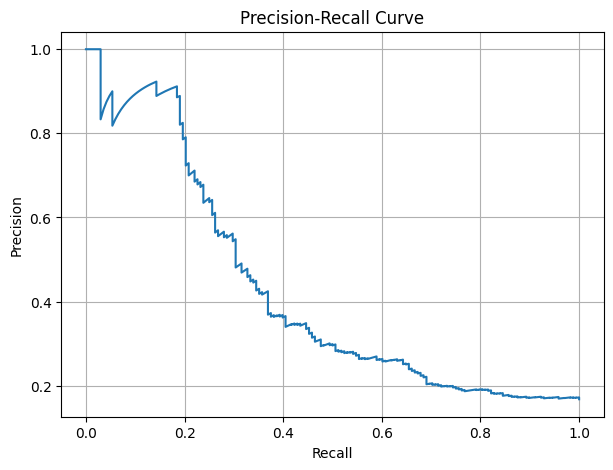

In [35]:
plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.savefig(
    RESULTS_DIR / "pr_curve_voting.png"
)

plt.show()

In [36]:
f1_scores = []

for p, r in zip(precision[:-1], recall[:-1]):

    f1 = (2 * p * r) / (p + r + 1e-10)

    f1_scores.append(f1)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.46872985789695887


In [37]:
sample_size = min(500, len(X_val))

random_indices = np.random.choice(
    len(X_val),
    sample_size,
    replace=False
)

X_shap = X_val.iloc[random_indices]

In [38]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_shap)

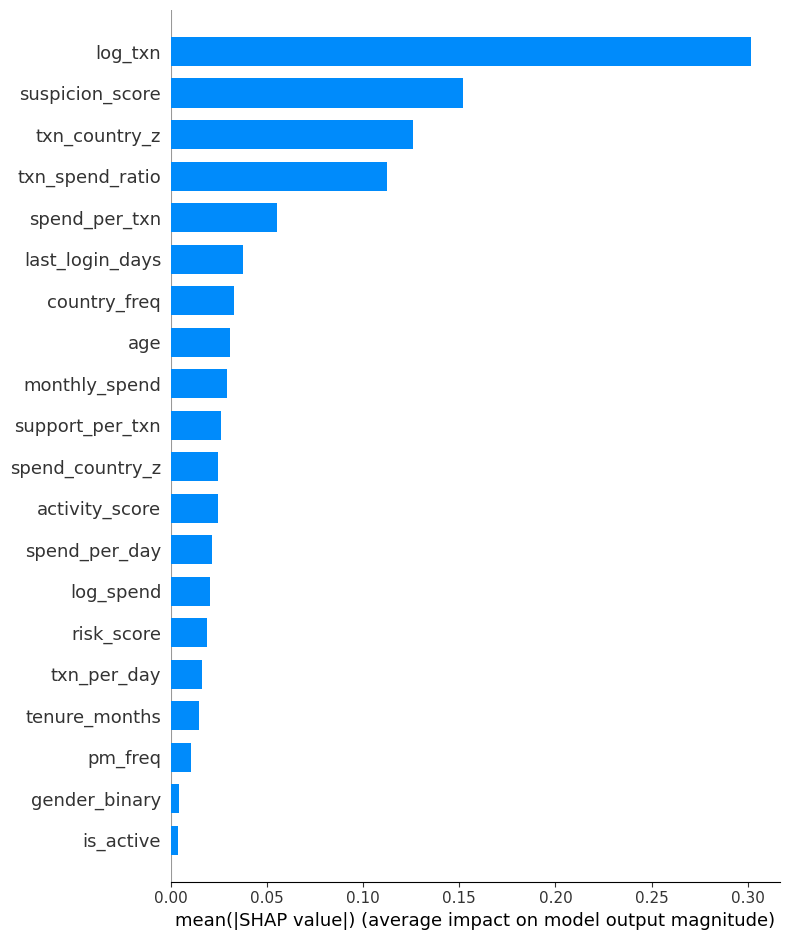

In [39]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_train.columns,
    plot_type='bar',
    show=False
)

plt.savefig(
    SHAP_DIR / "global_feature_importance.png",
    bbox_inches='tight'
)

plt.show()

In [40]:
voting_pred = (
    voting_val_prob >= best_threshold
).astype(int)

false_negative_indices = np.where(
    (y_val == 1) & (voting_pred == 0)
)[0]

print(false_negative_indices[:5])

[ 8 12 21 22 29]


In [41]:
evaluate_model(y_val, voting_pred)

{'Precision': 0.4246575342465753,
 'Recall': 0.36904761904761907,
 'F1': 0.39490445859872614,
 'PR_AUC': np.float64(0.26271885192433136)}

In [42]:
for idx in false_negative_indices[:3]:

    shap.force_plot(
        explainer.expected_value,
        explainer.shap_values(X_val[idx:idx+1])[0],
        X_val[idx:idx+1],
        matplotlib=True,
        show=False
    )

    plt.savefig(
        SHAP_DIR / f"false_negative_{idx}.png",
        bbox_inches='tight'
    )

    plt.close()

In [43]:
final_bundle = {
    "model": voting_clf,
    "threshold": best_threshold
}

joblib.dump(
    final_bundle,
    RESULTS_DIR / "fraud_model.pkl"
)

['results\\fraud_model.pkl']

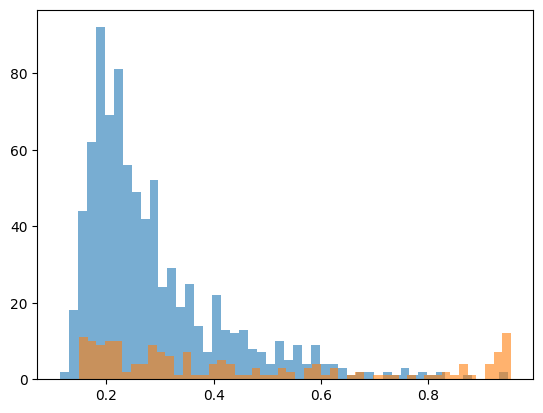

In [44]:
plt.hist(voting_val_prob[y_val==0], bins=50, alpha=0.6)
plt.hist(voting_val_prob[y_val==1], bins=50, alpha=0.6)

plt.show()

In [45]:
from sklearn.metrics import average_precision_score

average_precision_score(y_val, voting_val_prob)

np.float64(0.4266947772096725)